In [1]:
import numpy as np
import matplotlib.pyplot as plt
import astropy
from astropy.cosmology import Planck15
import astropy.cosmology as cosmo
import astropy.units as u
import matplotlib.colors as mcolors
import pandas as pd
import seaborn as sns
import matplotlib.patheffects as path_effects
from tqdm import tqdm
import dill
%run /home/jessica/Jess/Projects/Ongoing/Cosmography/Python/Colab/wcdm_expansions.ipynb

In [2]:
# Open the file and load the sampler object
with open("sampler_log.pkl", "rb") as f:
    sampler_order_log = dill.load(f)

# with open("sampler_z.pkl", "rb") as f:
#     sampler_order_z = dill.load(f)

In [3]:
with open("sampler_pade21.pkl", "rb") as f:
    sampler_pade21 = dill.load(f)

with open("sampler_pade22.pkl", "rb") as f:
    sampler_pade22 = dill.load(f)

with open("sampler_pade32.pkl", "rb") as f:
    sampler_pade32 = dill.load(f)

with open("sampler_pade42.pkl", "rb") as f:
    sampler_pade42 = dill.load(f)

with open("sampler_padeav.pkl", "rb") as f:
    sampler_padeav = dill.load(f)

# Concatenate the chains along the first axis
sampler_pade = np.concatenate([sampler_pade21, sampler_pade22, sampler_pade32, sampler_pade42], axis=0)

In [13]:
len(sampler_order_log)

3

In [5]:
H0 =  73.5
Om = 0.334
Ok = 0.0
w = -1.0

H0t, q0t, j0t, s0t, c0t, p0t = to_cosmographic(H0, Om, Ok, w)
theta_truue = (H0t, q0t, j0t, s0t, c0t, p0t)
print(theta_truue)

(73.5, -0.4989999999999999, 1.0, -0.5030000000000019, 3.508006000000009, -13.29954500599996)


In [11]:
def matrix_plot_posteriors(title, theta_true, sampler, ordermin=0):
    # Unpack true parameter values
    H0t, q0t, j0t, s0t, c0t, p0t = theta_true

    H0_samples = [np.full(1,np.nan), np.full(1,np.nan), np.full(1,np.nan), np.full(1,np.nan), np.full(1,np.nan)]
    q0_samples = [np.full(1,np.nan), np.full(1,np.nan), np.full(1,np.nan), np.full(1,np.nan), np.full(1,np.nan)]
    j0_samples = [np.full(1,np.nan), np.full(1,np.nan), np.full(1,np.nan), np.full(1,np.nan), np.full(1,np.nan)]
    s0_samples = [np.full(1,np.nan), np.full(1,np.nan), np.full(1,np.nan), np.full(1,np.nan), np.full(1,np.nan)]
    c0_samples = [np.full(1,np.nan), np.full(1,np.nan), np.full(1,np.nan), np.full(1,np.nan), np.full(1,np.nan)]
    p0_samples = [np.full(1,np.nan), np.full(1,np.nan), np.full(1,np.nan), np.full(1,np.nan), np.full(1,np.nan)]

    for i in range(len(sampler_order_log)):
        samples = sampler_order_log[i].get_chain(discard=500, thin=10, flat=True)
        if len(samples[0])==1:
            #H0_samples[i] = samples[:, 0]
            q0_samples[i] = samples[:, 0]
        elif len(samples[0]) ==2:
            #H0_samples[i] = samples[:, 0]
            q0_samples[i] = samples[:, 0]
            j0_samples[i] = samples[:, 1]
        elif len(samples[0]) ==3:
            #H0_samples[i] = samples[:, 0]
            q0_samples[i] = samples[:, 0]
            j0_samples[i] = samples[:, 1]
            s0_samples[i] = samples[:, 2]
        elif len(samples[0]) ==4:
            #H0_samples[i] = samples[:, 0]
            q0_samples[i] = samples[:, 0]
            j0_samples[i] = samples[:, 1]
            s0_samples[i] = samples[:, 2]
            c0_samples[i] = samples[:, 3]
        else:
            #H0_samples[i] = samples[:, 0]
            q0_samples[i] = samples[:, 0]
            j0_samples[i] = samples[:, 1]
            s0_samples[i] = samples[:, 2]
            c0_samples[i] = samples[:, 3]
            p0_samples[i] = samples[:, 4]

    # Number of columns (based on the ordermin parameter)
    order = len(sampler) #5  -ordermin
    pars = 5
    
    # List of samples and true values for easy access
    samples_list = [q0_samples, j0_samples, s0_samples, c0_samples, p0_samples]
    true_values = [q0t, j0t, s0t, c0t, p0t]
    
    # Labels for the parameters
    param_labels = ['$q_0$', '$j_0$', '$s_0$', '$c_0$', '$p_0$']
    order_labels = []
    for j in range(order):
        if title == 'Pade series':
            order_labels = ['Pade 21', 'Pade22', 'Pade32', 'Pade 42']
        else:
            order_labels.append('$\mathcal{O}(' + str(j+4+ordermin) + ')$')
    
    # Create the figure and axes for the matrix plot
    fig, axes = plt.subplots(pars, order, figsize=(10, 10))

    # Set title for the entire figure
    fig.suptitle(f'{title} (GRB redshift)', fontsize=18, weight='bold')

    # Loop through the grid and plot KDEs
    for i in range(order):
        for j in range(pars):
            ax = axes[j, i]

            # Get the posterior samples and true value for the current parameter
            if ~np.isnan(samples_list[j][i][0]):  # Make sure there are samples
                samples = samples_list[j][i] #if i < len(samples_list[j]) else []
                true_val = true_values[j]

                if len(samples) > 0:  # Plot KDE only if samples exist
                    sns.kdeplot(samples, fill=True, ax=ax, alpha=0.5, legend=False, color= 'mediumslateblue')
                    plt.ylabel('')
                    # Plot the true value line
                    ax.axvline(true_val, color='black', linestyle='--')
                    if j==0:
                        ax.set_title(order_labels[i], fontsize=16, weight='bold')

            # Remove density ylabel
            ax.set_yticks([])
            
            # Turn off empty cells
            if np.isnan(samples_list[j][i][0]):
                ax.axis('off')

            # Add parameter labels on the left side
            if i == len(sampler)-1:
                ax.yaxis.set_label_position("right")
                ax.set_ylabel(param_labels[j], fontsize=16, weight='bold')
            else:
                ax.set_ylabel('')


    # Adjust layout to eliminate space between subplots
    plt.subplots_adjust(wspace=-4, hspace=-1)  # Remove horizontal/vertical spaces

    # Adjust layout to avoid overlap
    plt.tight_layout()
    plt.savefig(f'Posteriors_matrix_{title}_GRB.png', dpi=500,  bbox_inches='tight')  # To save as PNG

    # Show the plot
    plt.show()

<>:55: SyntaxWarning: invalid escape sequence '\m'
<>:55: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_19194/403833668.py:55: SyntaxWarning: invalid escape sequence '\m'
  order_labels.append('$\mathcal{O}(' + str(j+3+ordermin) + ')$')


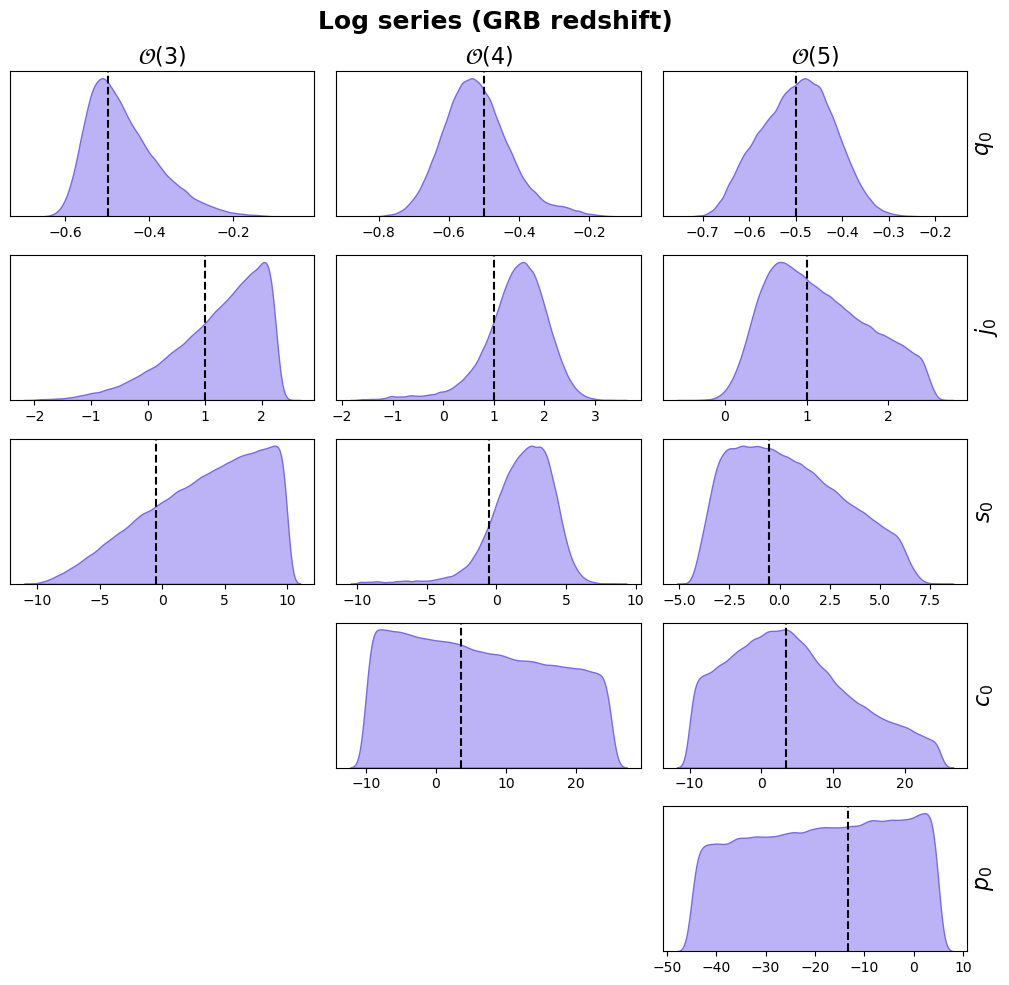

In [14]:
matrix_plot_posteriors('Log series', theta_truue, sampler_order_log, ordermin=0)

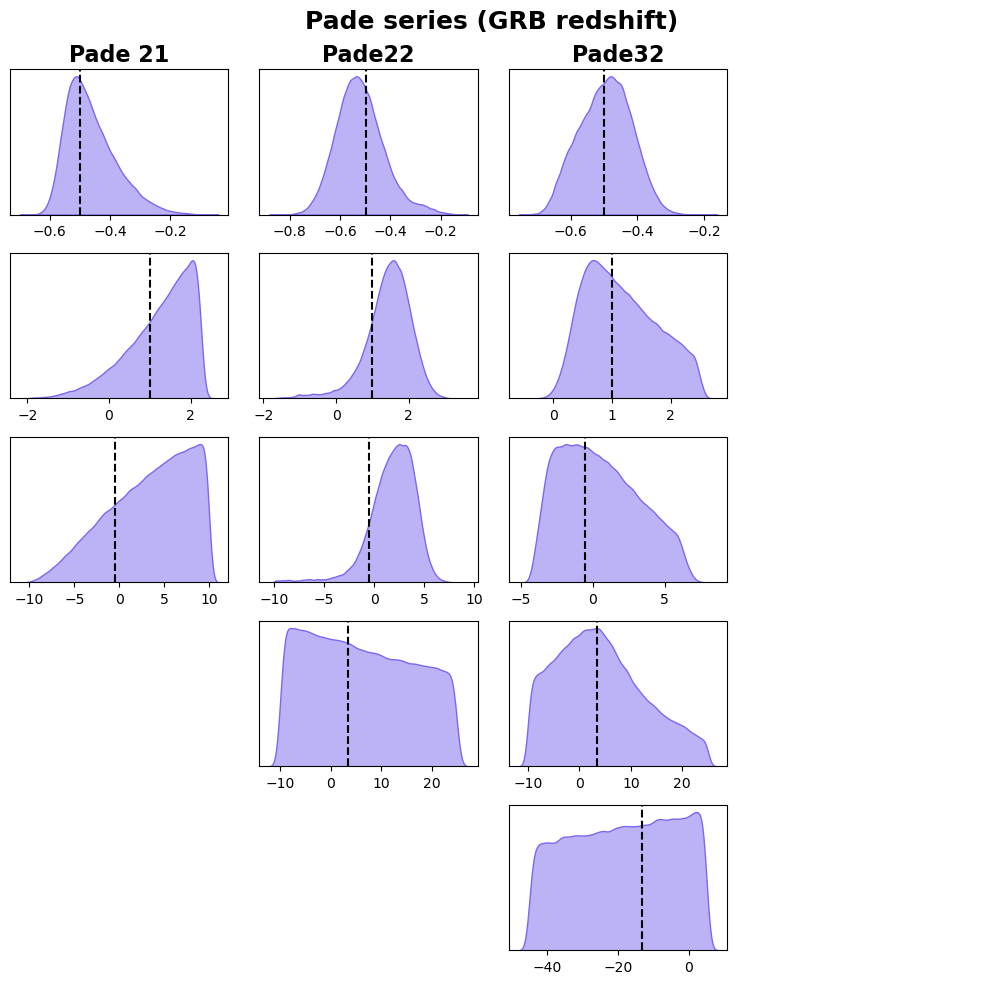

In [15]:
matrix_plot_posteriors('Pade series', theta_truue, sampler_pade , ordermin=1)

In [11]:
#matrix_plot_posteriors('z series', theta_truue, sampler_order_z, ordermin=0)

# Alternative styles

In [ ]:
# from matplotlib.ticker import StrMethodFormatter

# def matrix_plot_posteriors2(title, theta_true, sampler, ordermin=0):
#     # Unpack true parameter values
#     H0t, q0t, j0t, s0t, c0t, p0t = theta_true

#     H0_samples = [np.full(1,np.nan), np.full(1,np.nan), np.full(1,np.nan), np.full(1,np.nan), np.full(1,np.nan)]
#     q0_samples = [np.full(1,np.nan), np.full(1,np.nan), np.full(1,np.nan), np.full(1,np.nan), np.full(1,np.nan)]
#     j0_samples = [np.full(1,np.nan), np.full(1,np.nan), np.full(1,np.nan), np.full(1,np.nan), np.full(1,np.nan)]
#     s0_samples = [np.full(1,np.nan), np.full(1,np.nan), np.full(1,np.nan), np.full(1,np.nan), np.full(1,np.nan)]
#     c0_samples = [np.full(1,np.nan), np.full(1,np.nan), np.full(1,np.nan), np.full(1,np.nan), np.full(1,np.nan)]
#     p0_samples = [np.full(1,np.nan), np.full(1,np.nan), np.full(1,np.nan), np.full(1,np.nan), np.full(1,np.nan)]

#     for i in range(len(sampler_order_log)):
#         samples = sampler_order_log[i].get_chain(discard=500, thin=10, flat=True)
#         if len(samples[0])==2:
#             H0_samples[i] = samples[:, 0]
#             q0_samples[i] = samples[:, 1]
#         elif len(samples[0]) ==3:
#             H0_samples[i] = samples[:, 0]
#             q0_samples[i] = samples[:, 1]
#             j0_samples[i] = samples[:, 2]
#         elif len(samples[0]) ==4:
#             H0_samples[i] = samples[:, 0]
#             q0_samples[i] = samples[:, 1]
#             j0_samples[i] = samples[:, 2]
#             s0_samples[i] = samples[:, 3]
#         elif len(samples[0]) ==5:
#             H0_samples[i] = samples[:, 0]
#             q0_samples[i] = samples[:, 1]
#             j0_samples[i] = samples[:, 2]
#             s0_samples[i] = samples[:, 3]
#             c0_samples[i] = samples[:, 4]
#         else:
#             H0_samples[i] = samples[:, 0]
#             q0_samples[i] = samples[:, 1]
#             j0_samples[i] = samples[:, 2]
#             s0_samples[i] = samples[:, 3]
#             c0_samples[i] = samples[:, 4]
#             p0_samples[i] = samples[:, 5]

#     # Number of columns (based on the ordermin parameter)
#     order = 5  
#     pars = 6
    
#     # List of samples and true values for easy access
#     samples_list = [H0_samples, q0_samples, j0_samples, s0_samples, c0_samples, p0_samples]
#     true_values = [H0t, q0t, j0t, s0t, c0t, p0t]
    
#     # Labels for the parameters
#     param_labels = ['$H_0$', '$q_0$', '$j_0$', '$s_0$', '$c_0$', '$p_0$']
#     order_labels = []
#     for j in range(order):
#         order_labels.append('$\mathcal{O}(' + str(j+2) + ')$')
    
#     # Create the figure and axes for the matrix plot
#     fig, axes = plt.subplots(order, pars, figsize=(10, 8))

#     # Set title for the entire figure
#     fig.suptitle('MCMC Posterior Distributions', fontsize=16)

#     # Loop through the grid and plot KDEs
#     for i in range(order):
#         for j in range(pars):
#             ax = axes[i, j]

#             # Get the posterior samples and true value for the current parameter
#             if ~np.isnan(samples_list[j][i][0]):  # Make sure there are samples
#                 samples = samples_list[j][i] #if i < len(samples_list[j]) else []
#                 true_val = true_values[j]

#                 if len(samples) > 0:  # Plot KDE only if samples exist
#                     sns.despine()
#                     sns.kdeplot(samples, fill=True, ax=ax, alpha=0.5, legend=False)
#                     plt.ylabel('')
#                     # Plot the true value line
#                     ax.axvline(true_val, color='black', linestyle='--')
#                     #plt.tick_params(axis='both', which='major', labelsize=8)
#                     # plt.xticks(fontsize=4)
#                     # plt.yticks(fontsize=4)


#             # Turn off empty cells
#             if np.isnan(samples_list[j][i][0]):
#                 ax.axis('off')

#             # Add parameter labels on the left side
#             if i == 4:
#                 ax.set_xlabel(param_labels[j], fontsize=12)
#             else:
#                 ax.set_xlabel('')
#                 plt.xticks([])
#                 plt.gca().xaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}')) # No decimal places
#             # Add order labels on the bottom
#             if j == 0:
#                 ax.set_ylabel(order_labels[i], fontsize=12)
#             else:
#                 ax.set_ylabel('')
#                 ax.set_yticks([])

#     # Adjust layout to eliminate space between subplots
#     plt.subplots_adjust(wspace=-4, hspace=-1)  # Remove horizontal/vertical spaces

#     # Adjust layout to avoid overlap
#     plt.tight_layout()
#     #plt.subplots_adjust(top=0.5)  # Leave space for the title
    
#     # Show the plot
#     plt.show()

In [ ]:
# matrix_plot_posteriors2('MCMC Posterior Distributions', theta_truue, sampler_order_log, ordermin=0)

In [355]:
# import seaborn as sns
# import pandas as pd
# import numpy as np
# import matplotlib.pyplot as plt
# data_list =[]
# df_list = []
# def matrix_plot_posteriors_facetgrid(title, theta_true, sampler, ordermin=0):
#     # Unpack true parameter values
#     H0t, q0t, j0t, s0t, c0t, p0t = theta_true

#     H0_samples = [np.full(1, np.nan)] * 5
#     q0_samples = [np.full(1, np.nan)] * 5
#     j0_samples = [np.full(1, np.nan)] * 5
#     s0_samples = [np.full(1, np.nan)] * 5
#     c0_samples = [np.full(1, np.nan)] * 5
#     p0_samples = [np.full(1, np.nan)] * 5

#     for i in range(len(sampler)):
#         samples = sampler[i].get_chain(discard=500, thin=10, flat=True)
#         if len(samples[0]) == 2:
#             H0_samples[i], q0_samples[i] = samples[:, 0], samples[:, 1]
#         elif len(samples[0]) == 3:
#             H0_samples[i], q0_samples[i], j0_samples[i] = samples[:, 0], samples[:, 1], samples[:, 2]
#         elif len(samples[0]) == 4:
#             H0_samples[i], q0_samples[i], j0_samples[i], s0_samples[i] = samples[:, 0], samples[:, 1], samples[:, 2], samples[:, 3]
#         elif len(samples[0]) == 5:
#             H0_samples[i], q0_samples[i], j0_samples[i], s0_samples[i], c0_samples[i] = samples[:, 0], samples[:, 1], samples[:, 2], samples[:, 3], samples[:, 4]
#         else:
#             H0_samples[i], q0_samples[i], j0_samples[i], s0_samples[i], c0_samples[i], p0_samples[i] = samples[:, 0], samples[:, 1], samples[:, 2], samples[:, 3], samples[:, 4], samples[:, 5]

#     # List of samples and true values for easy access
#     samples_list = [H0_samples, q0_samples, j0_samples, s0_samples, c0_samples, p0_samples]
#     param_labels = ['$H_0$', '$q_0$', '$j_0$', '$s_0$', '$c_0$', '$p_0$']
#     order = 5  
#     order_labels = []
#     for j in range(order):
#         order_labels.append('$\mathcal{O}(' + str(j+2) + ')$')

#     # Combine the samples into a long DataFrame
#     data = []
#     for param_idx, samples in enumerate(samples_list):
#         for order_idx, order_samples in enumerate(samples):
#             if not np.isnan(order_samples[0]):  # Only add valid samples
#                 for sample in order_samples:
#                     data.append([sample, param_labels[param_idx], order_labels[order_idx]])
    
#     # Create the DataFrame
#     df = pd.DataFrame(data, columns=['Value', 'Parameter', 'Order'])
#     data_list.append(data)
#     data_list.append(df)

#     # True values for vertical lines
#     # true_values = {param_labels[i]: val for i, val in enumerate(theta_true)}

#     # Create the FacetGrid with rows as parameters and columns as orders
#     g = sns.FacetGrid(df, row="Parameter", col="Order", sharex=False, sharey=False, aspect=1, margin_titles=True)

#     # Plot KDEs in each facet
#     g.map(sns.kdeplot, "Value", fill=True, alpha=0.5)

#     # for ax, (row_val, col_val) in zip(g.axes.flat, g.facet_data()):
#     # #for ax, (row_val, col_val) in enumerate(zip(g.axes.flat,  g.facet_data())):
#     #     # Extract the parameter index (row) and order index (column)

#     #     param = row_val[0]  # Get the parameter from row_val
#     #     #print(col_val['Order'])#, len(col_val))

#     #     for k in range(len(col_val['Order'])):
#     #         if col_val['Order'].iloc[0][k] == '$\mathcal{O}(2)$':
#     #             print('hey yo')

#         # param_idx = row_val[0]  # Assuming row_val is a tuple like (0, 0, 0)
#         # order_idx = col_val[0]  # Adjust index extraction based on the actual structure
    
#         # param = param_labels[param_idx]  # Get the parameter label
#         # order = order_labels[order_idx]  # Get the order label
    
#         # # Check if the DataFrame has valid samples for the current parameter and order
#         # filtered_samples = df[(df['Parameter'] == param) & (df['Order'] == order)]
    
#         # # Turn off the axis if no valid samples
#         # if filtered_samples.empty:
#         #     ax.set_axis_off()
#         # else:
#         #     true_val = true_values.get(param, None)
#         #     if true_val is not None:
#         #         ax.axvline(true_val, color='red', linestyle='--')

    
#     # # Loop over the grid axes and customize the plot
#     # for ax, (row_val, col_val) in zip(g.axes.flat, g.facet_data()):
#     #     param = row_val  # Use row_val directly as the parameter label
#     #     order = col_val  # Use col_val directly as the order label
        
#     #     # Find the true value for the current parameter
#     #     true_val = true_values.get(param, None)
        
#     #     # Get the posterior samples for the current subplot (use param and order as needed)
#     #     if true_val is not None:
#     #         ax.axvline(true_val, color='black', linestyle='--')
    
#     #     # Turn off the axis if no valid samples
#     #     #samples = df[(df['Parameter'] == param) & (df['Order'] == order)]
#     #     # Extract the correct strings for the parameter and order
#     #     param_str = str(param)
#     #     order_str = str(order)
#     #     print(param, order)

#     #     # Check if the DataFrame has valid samples for the current parameter and order
#     #     filtered_samples = df[(df['Parameter'] == param_str) & (df['Order'] == order_str)]

#     #     # Turn off the axis if no valid samples
#     #     if filtered_samples.empty:
#     #         ax.set_axis_off()

#     # for ax, (row_val, col_val) in zip(g.axes.flat, g.facet_data()):
#     #     param = row_val[0]  # Extract the parameter (row label)
#     #     order = col_val[0]  # Extract the order (col label)

#     #     # Find the true value for the current parameter
#     #     true_val = true_values.get(param, None)

#     #     # Plot the vertical line for the true value
#     #     if true_val is not None:
#     #         ax.axvline(true_val, color='red', linestyle='--')

#     #     # Add labels only for the last column and bottom row
#     #     if ax.is_last_row():
#     #         ax.set_xlabel(param)
#     #     else:
#     #         ax.set_xlabel('')
#     #         ax.set_xticks([])

#     #     if ax.is_first_col():
#     #         ax.set_ylabel(order)
#     #     else:
#     #         ax.set_ylabel('')
#     #         ax.set_yticks([])

#     #     # Turn off the axis if samples are NaN
#     #     if np.isnan(df[df["Parameter"] == param]["Value"].values).all():
#     #         ax.set_axis_off()


    
#     # Set the title
#     g.fig.suptitle(title, fontsize=16, y=1.03)

#     # Adjust layout
#     g.tight_layout()
#     plt.show()


<>:37: SyntaxWarning: invalid escape sequence '\m'
<>:37: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_16039/3710950439.py:37: SyntaxWarning: invalid escape sequence '\m'
  order_labels.append('$\mathcal{O}(' + str(j+2) + ')$')


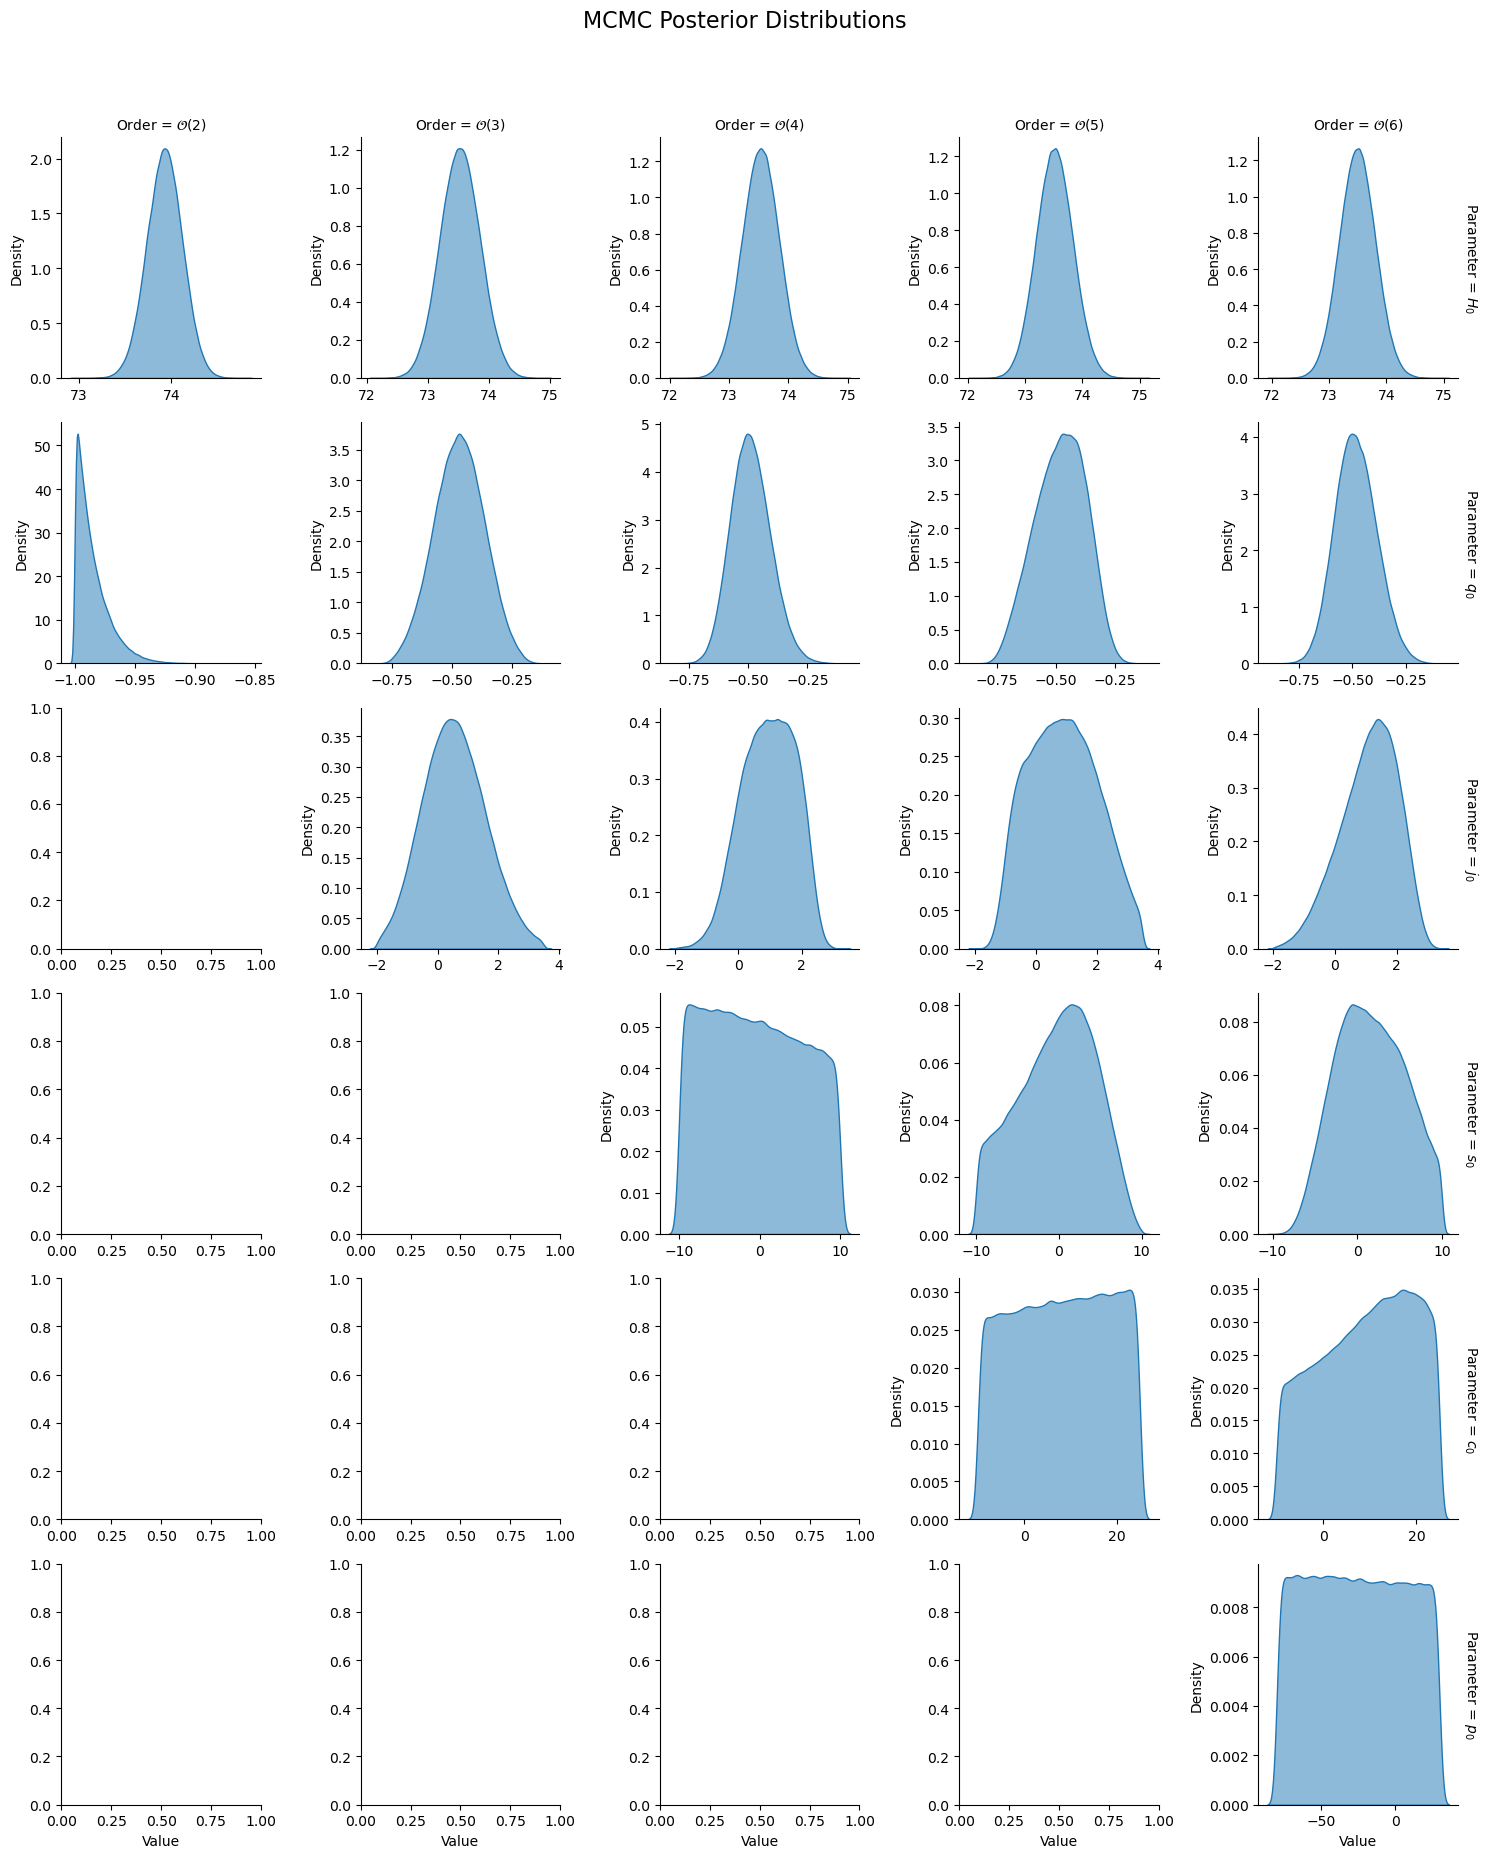

In [356]:
# matrix_plot_posteriors_facetgrid('MCMC Posterior Distributions', theta_truue, sampler_order_log, ordermin=0)